In [1]:
import os
import pandas as pd
from pathlib import Path
import sys

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed" 
PROCESSED_FEATURE_DIR = PROCESSED_DIR / "features"

sys.path.append(str(BASE_DIR))

feature_matrix_pipeline_dict = {
    "feature_matrix_stock": os.path.join(PROCESSED_FEATURE_DIR, "feature_matrix_stock.parquet"), 
    "feature_matrix_market": os.path.join(PROCESSED_FEATURE_DIR, "feature_matrix_market.parquet"), 
    "feature_matrix_macro_market": os.path.join(PROCESSED_FEATURE_DIR, "feature_matrix_macro_market.parquet")
}

In [97]:
COMPANIES_DIR = BASE_DIR / "data" / "raw" / "companies"

In [116]:
returns_df = pd.read_parquet(os.path.join(COMPANIES_DIR, "returns.parquet"))

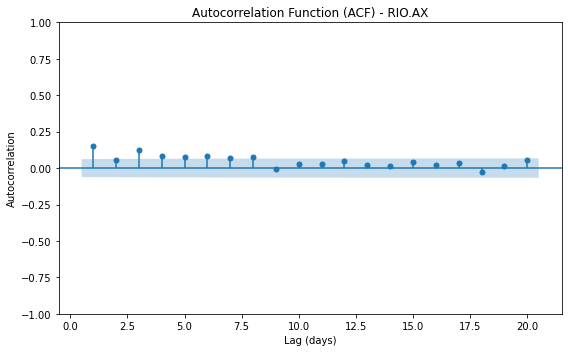

In [120]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

ticker = "RIO.AX"   # Change this

returns = (
    returns_df.loc[:, ["Date", ticker]]
    .dropna()[ticker]
)

fig, ax = plt.subplots(figsize=(8, 5))

plot_acf(
    returns ** 2,
    lags=20,
    alpha=0.05,      # 95% confidence bands
    zero=False,
    ax=ax
)

ax.set_title(f"Autocorrelation Function (ACF) - {ticker}")
ax.set_xlabel("Lag (days)")
ax.set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

In [2]:
from scripts.models.lightgbm.tune_lightgbm import LightGBMTuner
from scripts.models.lightgbm.lightgbm_model import LightGBMRegressionModel
from scripts.models.walk_forward import WalkForwardValidator

In [4]:
feature_matrix_stock = pd.read_parquet(feature_matrix_pipeline_dict["feature_matrix_stock"])
feature_matrix_market = pd.read_parquet(feature_matrix_pipeline_dict["feature_matrix_market"])
feature_matrix_macro_market = pd.read_parquet(feature_matrix_pipeline_dict["feature_matrix_macro_market"])

In [5]:
LightGBMTuner(20, 42, feature_matrix_market).run_data()

1/20: IC = 0.01719
2/20: IC = 0.01861
3/20: IC = 0.01648
4/20: IC = 0.00802
5/20: IC = 0.03440
6/20: IC = 0.00957
7/20: IC = -0.00114
8/20: IC = 0.02113
9/20: IC = -0.00555
10/20: IC = 0.00046
11/20: IC = 0.02216
12/20: IC = -0.00898
13/20: IC = 0.00032
14/20: IC = -0.00013
15/20: IC = -0.00416
16/20: IC = 0.02201
17/20: IC = 0.00479
18/20: IC = 0.00176
19/20: IC = 0.00640
20/20: IC = -0.00275


In [6]:
import pandas as pd

In [6]:
LightGBMTuner(40, 42, feature_matrix_market).run_data()

1/40: IC = 0.02602
2/40: IC = 0.02657
3/40: IC = 0.02549
4/40: IC = 0.00794
5/40: IC = 0.02701
6/40: IC = 0.00247
7/40: IC = 0.00323
8/40: IC = 0.02304
9/40: IC = 0.01442
10/40: IC = 0.01022
11/40: IC = 0.01708
12/40: IC = 0.00872
13/40: IC = 0.00862
14/40: IC = 0.00766
15/40: IC = 0.00043
16/40: IC = 0.02353
17/40: IC = 0.00587
18/40: IC = 0.00669
19/40: IC = 0.00840
20/40: IC = 0.01388
21/40: IC = 0.02182
22/40: IC = -0.00527
23/40: IC = 0.00204
24/40: IC = 0.00102
25/40: IC = 0.00309
26/40: IC = 0.00999
27/40: IC = 0.02010
28/40: IC = 0.02877
29/40: IC = 0.02768
30/40: IC = 0.02854
31/40: IC = -0.00266
32/40: IC = -0.00308
33/40: IC = 0.01355
34/40: IC = 0.02182
35/40: IC = 0.01173
36/40: IC = 0.01599
37/40: IC = -0.00266
38/40: IC = 0.00133
39/40: IC = 0.02477
40/40: IC = 0.00131


In [81]:
import pandas as pd

results_df = pd.read_csv(os.path.join(BASE_DIR, "results/lightgbm_model/random_search.csv"))

print(results_df.head())

   learning_rate  num_leaves  max_depth  n_estimators  min_child_samples  \
0           0.01          31          9           200                 20   
1           0.02          63          9           100                 20   
2           0.04          63          9           100                100   
3           0.02         127          5           100                100   
4           0.01          31          5           200                 20   

    mean_ic  
0  0.033448  
1  0.026644  
2  0.026107  
3  0.022539  
4  0.021323  


In [82]:
import json

In [83]:
with open(os.path.join(BASE_DIR, "results/lightgbm_model/best_params.json"), "r") as f:
    best_params = json.load(f)

In [84]:
int_params = [
    "num_leaves",
    "max_depth",
    "n_estimators",
    "min_child_samples",
]

for p in int_params:
    best_params[p] = int(best_params[p])

In [85]:
model = LightGBMRegressionModel(params=best_params)

wf = WalkForwardValidator(
    feature_matrix=feature_matrix_subset,
    model=model,
    validation_start="2025-01-01",
    validation_end="2026-12-31",
    rebalance_date=1,
    min_train_size=30_000,
)

X_test, test_preds = wf.run_data()

daily_ic = test_preds.groupby("Date").apply(
    lambda x: x["prediction"].corr(
        x["future_return_5d"],
        method="spearman",
    )
)

mean_ic = daily_ic.dropna().mean()

In [87]:
mean_ic

0.01980785771830621

In [86]:
test_preds

,Date,Ticker,future_return_5d,prediction,model_name
0,2025-01-07,360.AX,-0.092301,0.007364,LightGBMRegressionModel
1,2025-01-07,4DX.AX,-0.045872,0.011502,LightGBMRegressionModel
2,2025-01-07,A2M.AX,-0.005310,0.004301,LightGBMRegressionModel
3,2025-01-07,AAI.AX,0.004597,0.007716,LightGBMRegressionModel
4,2025-01-07,AGL.AX,0.026786,0.002577,LightGBMRegressionModel
...,...,...,...,...,...
14630,2026-06-02,XRO.AX,-0.117011,0.003038,LightGBMRegressionModel
14631,2026-06-02,XYZ.AX,-0.081132,0.004177,LightGBMRegressionModel
14632,2026-06-02,YAL.AX,-0.075912,0.003503,LightGBMRegressionModel
14633,2026-06-02,ZIM.AX,-0.063725,0.007896,LightGBMRegressionModel


In [62]:
test_preds

,Date,Ticker,future_return_5d,prediction,model_name
0,2025-01-07,360.AX,-0.092301,0.008235,LightGBMRegressionModel
1,2025-01-07,4DX.AX,-0.045872,0.011259,LightGBMRegressionModel
2,2025-01-07,A2M.AX,-0.005310,0.004833,LightGBMRegressionModel
3,2025-01-07,AAI.AX,0.004597,0.006281,LightGBMRegressionModel
4,2025-01-07,AGL.AX,0.026786,0.000018,LightGBMRegressionModel
...,...,...,...,...,...
14630,2026-06-02,XRO.AX,-0.117011,0.002264,LightGBMRegressionModel
14631,2026-06-02,XYZ.AX,-0.081132,0.003784,LightGBMRegressionModel
14632,2026-06-02,YAL.AX,-0.075912,0.003665,LightGBMRegressionModel
14633,2026-06-02,ZIM.AX,-0.063725,0.005996,LightGBMRegressionModel


In [11]:
test_preds

,Date,Ticker,future_return_5d,prediction,model_name
0,2026-01-06,360.AX,-0.010645,0.006775,LightGBMRegressionModel
1,2026-01-06,4DX.AX,0.023866,0.040542,LightGBMRegressionModel
2,2026-01-06,A2M.AX,0.016575,0.003937,LightGBMRegressionModel
3,2026-01-06,AAI.AX,0.072621,0.003289,LightGBMRegressionModel
4,2026-01-06,AGL.AX,-0.026316,0.003052,LightGBMRegressionModel
...,...,...,...,...,...
4395,2026-06-02,XRO.AX,-0.117011,0.000539,LightGBMRegressionModel
4396,2026-06-02,XYZ.AX,-0.081132,0.002522,LightGBMRegressionModel
4397,2026-06-02,YAL.AX,-0.075912,0.003860,LightGBMRegressionModel
4398,2026-06-02,ZIM.AX,-0.063725,0.008691,LightGBMRegressionModel


In [14]:
test_preds.tail(20)

,Date,Ticker,future_return_5d,prediction,model_name
14615,2026-06-02,TWE.AX,0.150852,0.003058,LightGBMRegressionModel
14616,2026-06-02,VAU.AX,-0.132420,0.004760,LightGBMRegressionModel
14617,2026-06-02,VCX.AX,0.057851,0.002377,LightGBMRegressionModel
14618,2026-06-02,VEA.AX,0.079439,0.004567,LightGBMRegressionModel
14619,2026-06-02,VGN.AX,0.003788,0.002527,LightGBMRegressionModel
14620,2026-06-02,VNT.AX,0.019048,0.001519,LightGBMRegressionModel
14621,2026-06-02,WAF.AX,-0.118750,0.001105,LightGBMRegressionModel
14622,2026-06-02,WBC.AX,-0.005058,0.002088,LightGBMRegressionModel
14623,2026-06-02,WDS.AX,-0.005447,0.003790,LightGBMRegressionModel
14624,2026-06-02,WES.AX,0.053569,0.001519,LightGBMRegressionModel


<AxesSubplot:xlabel='Date', ylabel='future_return_5d'>

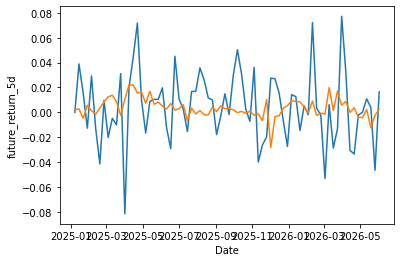

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(test_preds[test_preds["Ticker"] == "ANZ.AX"], x= "Date", y="future_return_5d")
sns.lineplot(test_preds[test_preds["Ticker"] == "ANZ.AX"], x= "Date", y="prediction")

<AxesSubplot:xlabel='Date', ylabel='future_return_5d'>

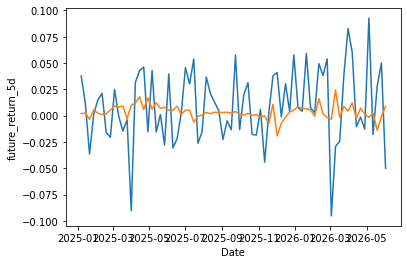

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(test_preds[test_preds["Ticker"] == "BHP.AX"], x= "Date", y="future_return_5d")
sns.lineplot(test_preds[test_preds["Ticker"] == "BHP.AX"], x= "Date", y="prediction")

<AxesSubplot:xlabel='Date'>

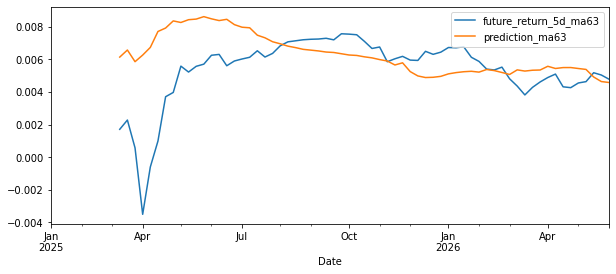

In [46]:
tmp = test_preds.sort_values("Date").copy()

daily_avg = (
    tmp.groupby("Date")[["future_return_5d", "prediction"]]
       .mean()
       .reset_index()
)

daily_avg["future_return_5d_ma63"] = (
    daily_avg["future_return_5d"]
    .rolling(63, min_periods=10)
    .mean()
)

daily_avg["prediction_ma63"] = (
    daily_avg["prediction"]
    .rolling(63, min_periods=10)
    .mean()
)

daily_avg.plot(
    x="Date",
    y=["future_return_5d_ma63", "prediction_ma63"],
    figsize=(10, 4)
)

In [72]:
ticker = "NAB.AX"   # change this

tmp = (
    test_preds[test_preds["Ticker"] == ticker]
    .sort_values("Date")
    .copy()
)

tmp[["future_return_5d", "prediction"]].describe()

,future_return_5d,prediction
count,74.000000,74.000000
mean,0.001928,0.003707
std,0.035543,0.007810
min,-0.104277,-0.026264
25%,-0.017955,-0.000694
50%,0.005180,0.002882
75%,0.025357,0.007515
max,0.097973,0.022059


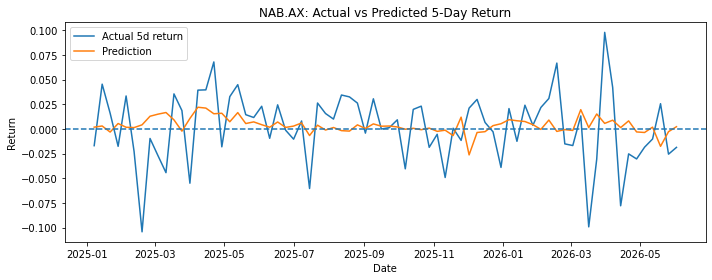

In [73]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(tmp["Date"], tmp["future_return_5d"], label="Actual 5d return")
ax.plot(tmp["Date"], tmp["prediction"], label="Prediction")

ax.axhline(0, linestyle="--")
ax.set_title(f"{ticker}: Actual vs Predicted 5-Day Return")
ax.set_xlabel("Date")
ax.set_ylabel("Return")
ax.legend()

plt.tight_layout()
plt.show()

<AxesSubplot:title={'center':'NAB.AX: Rolling Actual vs Prediction'}, xlabel='Date'>

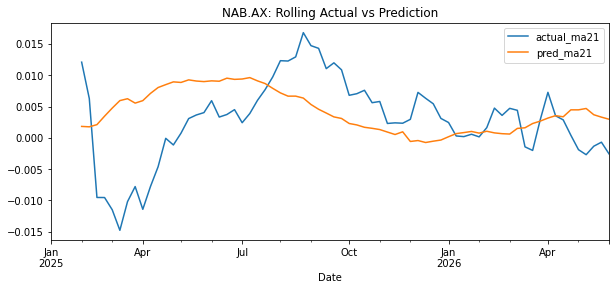

In [74]:
tmp["actual_ma21"] = tmp["future_return_5d"].rolling(21, min_periods=5).mean()
tmp["pred_ma21"] = tmp["prediction"].rolling(21, min_periods=5).mean()

tmp.plot(
    x="Date",
    y=["actual_ma21", "pred_ma21"],
    figsize=(10, 4),
    title=f"{ticker}: Rolling Actual vs Prediction"
)

In [18]:
test_preds[test_preds["Ticker"] == "CBA.AX"].tail(20)

,Date,Ticker,future_return_5d,prediction,model_name
10671,2026-01-20,CBA.AX,-0.000797,0.005862,LightGBMRegressionModel
10871,2026-01-27,CBA.AX,0.020057,0.005613,LightGBMRegressionModel
11071,2026-02-03,CBA.AX,0.036974,-0.000814,LightGBMRegressionModel
11271,2026-02-10,CBA.AX,0.121519,0.007514,LightGBMRegressionModel
11471,2026-02-17,CBA.AX,0.016052,-0.003701,LightGBMRegressionModel
11671,2026-02-24,CBA.AX,-0.025322,-0.002381,LightGBMRegressionModel
11871,2026-03-03,CBA.AX,-0.012530,-0.003861,LightGBMRegressionModel
12071,2026-03-10,CBA.AX,0.025145,0.020334,LightGBMRegressionModel
12271,2026-03-17,CBA.AX,-0.028390,-0.000389,LightGBMRegressionModel
12471,2026-03-24,CBA.AX,-0.019986,0.014370,LightGBMRegressionModel


In [10]:
mean_ic

0.021802123919010756

In [88]:
import shap
import numpy as np

explainer = shap.TreeExplainer(model.model)
shap_values = explainer.shap_values(X_test)

In [89]:
shap_importance = (
    pd.DataFrame({
        "feature": X_test.columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

In [90]:
shap_importance

,feature,mean_abs_shap
0,market_volatility_21d,0.001665
1,raw_garch_vol,0.001411
2,momentum_63_21,0.000702
3,industry_resid_vol_126,0.000639
4,market_resid_vol_126,0.000480
5,momentum_liquidity_21,0.000473
6,market_return_21d,0.000462
7,momentum_252_21_x,0.000421
8,market_beta_63,0.000375
9,market_drawdown_63d,0.000324


In [93]:
feature_matrix_subset = feature_matrix_market[["Date", "Ticker"] + shap_importance["feature"].tolist()[:10] + ["future_return_5d"]]

In [94]:
LightGBMTuner(20, 42, feature_matrix_subset).run_data()

1/20: IC = 0.00332
2/20: IC = 0.00304
3/20: IC = 0.00251
4/20: IC = 0.00109
5/20: IC = 0.00648
6/20: IC = 0.00095
7/20: IC = -0.00768
8/20: IC = 0.00571
9/20: IC = 0.00817
10/20: IC = 0.00012
11/20: IC = -0.00617
12/20: IC = 0.00000
13/20: IC = -0.00156
14/20: IC = 0.00588
15/20: IC = -0.00679
16/20: IC = 0.00681
17/20: IC = -0.00957
18/20: IC = -0.00039
19/20: IC = 0.00618
20/20: IC = -0.01091


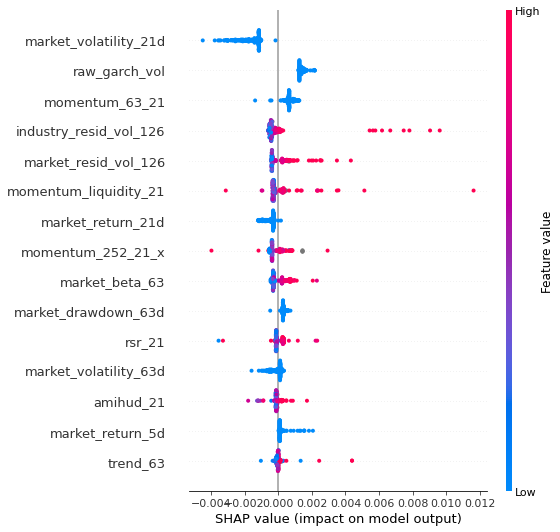

In [92]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=40
)

In [9]:
test_preds

,Date,Ticker,future_return_5d,prediction,model_name
0,2025-01-07,360.AX,-0.092301,0.008161,LightGBMRegressionModel
1,2025-01-07,4DX.AX,-0.045872,0.013369,LightGBMRegressionModel
2,2025-01-07,A2M.AX,-0.005310,0.005259,LightGBMRegressionModel
3,2025-01-07,AAI.AX,0.004597,0.005871,LightGBMRegressionModel
4,2025-01-07,AGL.AX,0.026786,0.000057,LightGBMRegressionModel
...,...,...,...,...,...
14630,2026-06-02,XRO.AX,-0.117011,0.001098,LightGBMRegressionModel
14631,2026-06-02,XYZ.AX,-0.081132,0.003740,LightGBMRegressionModel
14632,2026-06-02,YAL.AX,-0.075912,0.004971,LightGBMRegressionModel
14633,2026-06-02,ZIM.AX,-0.063725,0.007394,LightGBMRegressionModel


In [17]:
daily_ic.describe()

count    22.000000
mean      0.014099
std       0.264017
min      -0.469219
25%      -0.210645
50%       0.086294
75%       0.228590
max       0.393173
dtype: float64

In [20]:
0.014099/0.264


0.05340530303030303

In [14]:
positive_rate = (daily_ic > 0).mean()
print(positive_rate)

0.5909090909090909


In [15]:
bad_dates = daily_ic.sort_values().head(10).index

bad_preds = test_preds[test_preds["Date"].isin(bad_dates)].copy()

bad_summary = (
    bad_preds
    .groupby("Date")
    .agg(
        n_stocks=("Ticker", "count"),
        avg_target=("future_return_5d", "mean"),
        avg_prediction=("prediction", "mean"),
        std_target=("future_return_5d", "std"),
        std_prediction=("prediction", "std"),
    )
)

bad_summary

,n_stocks,avg_target,avg_prediction,std_target,std_prediction
Date,,,,,
2026-01-27,200,-0.029270,0.005065,0.051012,0.003680
2026-02-10,200,-0.021499,0.004554,0.058507,0.003547
2026-03-03,200,-0.038040,0.005076,0.062863,0.005247
2026-03-10,200,-0.023105,0.004555,0.059439,0.004869
2026-03-17,200,-0.029865,0.004303,0.069397,0.004738
2026-04-21,200,-0.029337,0.004164,0.055700,0.004296
2026-04-28,200,-0.001567,0.004105,0.047251,0.004295
2026-05-12,200,-0.008394,0.003979,0.069335,0.005043
2026-05-26,200,0.011444,0.003755,0.058224,0.004852


In [16]:
test_preds["prediction"].describe()

count    4400.000000
mean        0.004343
std         0.004352
min        -0.013644
25%         0.002304
50%         0.003073
75%         0.004953
max         0.049389
Name: prediction, dtype: float64

In [17]:
date = test_preds["Date"].iloc[0]

tmp = test_preds[test_preds["Date"] == date]

print(tmp["prediction"].describe())
print(tmp["future_return_5d"].describe())

count    200.000000
mean       0.004826
std        0.004869
min       -0.004225
25%        0.002722
50%        0.003496
75%        0.005118
max        0.043668
Name: prediction, dtype: float64
count    200.000000
mean       0.021588
std        0.043674
min       -0.070822
25%       -0.000645
50%        0.014969
75%        0.036197
max        0.258932
Name: future_return_5d, dtype: float64


In [18]:
date = test_preds["Date"].iloc[0]

tmp = test_preds[test_preds["Date"] == date].copy()

tmp[["prediction", "future_return_5d"]].corr(method="spearman")

,prediction,future_return_5d
prediction,1.000000,0.139225
future_return_5d,0.139225,1.000000


In [25]:
bad_date = "2026-06-02"

tmp = test_preds[test_preds["Date"] == bad_date].copy()

tmp.sort_values("prediction", ascending=False)[
    ["Ticker", "prediction", "future_return_5d"]
].head(20)

tmp.sort_values("prediction", ascending=True)[
    ["Ticker", "prediction", "future_return_5d"]
].head(20)

,Ticker,prediction,future_return_5d
4201,4DX.AX,-0.010669,-0.051948
4260,DRO.AX,-0.004666,-0.137072
4295,LLC.AX,0.002244,-0.026022
4248,CPU.AX,0.002244,0.038704
4268,EVT.AX,0.002244,0.052233
4370,SUN.AX,0.002244,0.062209
4209,ALL.AX,0.002244,0.037517
4310,MTS.AX,0.002244,0.043189
4303,MGR.AX,0.002244,0.052308
4355,SDF.AX,0.002244,0.341646


In [26]:
best_params

{'learning_rate': 0.01,
 'num_leaves': 15,
 'max_depth': 7,
 'n_estimators': 100,
 'min_child_samples': 100}

In [13]:
directional_accuracy = (
    (output_test["prediction"] > 0)
    ==
    (output_test["future_return_5d"] > 0)
).mean()

In [14]:
directional_accuracy

0.5171389109781107

Text(0, 0.5, 'Future Return 5D')

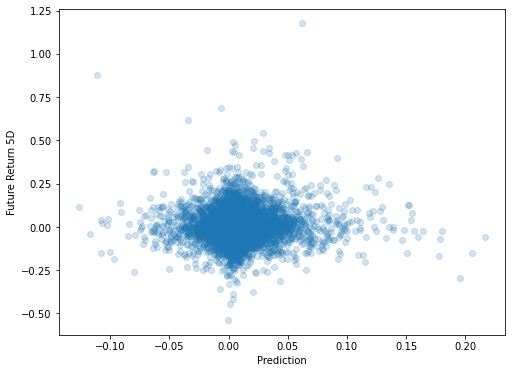

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    output_test["prediction"],
    output_test["future_return_5d"],
    alpha=0.2
)
plt.xlabel("Prediction")
plt.ylabel("Future Return 5D")

In [12]:
output_test["decile"] = pd.qcut(
    output_test["prediction"],
    10,
    labels=False,
    duplicates="drop"
)

output_test.groupby("decile")["future_return_5d"].mean()

decile
0    0.005893
1    0.003140
2    0.001767
3    0.001249
4    0.002874
5    0.003179
6    0.004238
7    0.004239
8    0.003262
9    0.013276
Name: future_return_5d, dtype: float64

In [7]:
output_test["future_return_5d"].corr(output_test["prediction"])

0.0303088088203395

In [8]:
daily_ic = (
    output_test
    .groupby("Date")
    .apply(lambda x: x["prediction"].corr(x["future_return_5d"]))
)

In [9]:
print(daily_ic.mean())
print(daily_ic.std())
print((daily_ic > 0).mean())

0.03964415067954155
0.16001704697145608
0.5737704918032787


In [ ]:
sns.scatterplot(data=output_test, x=)